
# Training Top-View Camera Vehicle Detection

### Truong Quoc Nam
Email: tr.qcnam2k8@gmail.com and 26521317@gm.uit.edu.vn     
First-year Computer Science Student at University of Information Technology, Vietnam National University HCMC

kaggle kernels pull trngqucnam/top-view-camera-vehicle-detection -m


kaggle kernels push -p . --no-run

# Variable and libary

Run before training

In [4]:
import yaml
from ultralytics  import YOLO
import os

device = [0,1]
data_yaml_path = '/kaggle/working/data.yaml'
checkpoint_dir = '/kaggle/working/runs/Top-View-Camera-Vehicle-Detection_v1/weights'

print("User>> ok")

User>> ok


# Data

In [4]:

data_yaml      = """
train: /kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/train/images
test: /kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/test/images
val: /kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/valid/images

nc: 3
names : ['bus', 'car', 'truck']
"""

with open(data_yaml_path, 'w') as f: f.write(data_yaml)
print("User>> Created data_yaml file.")

User>> Created data_yaml file.


In [5]:
with open(data_yaml_path, 'r') as f: data_conf = yaml.safe_load(f)
print(f"User>> Data_conf is {data_conf}")

User>> Data_conf is {'train': '/kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/train/images', 'test': '/kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/test/images', 'val': '/kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/valid/images', 'nc': 3, 'names': ['bus', 'car', 'truck']}


# Model

Create model

In [6]:
model = YOLO("yolo26s.pt") #Nhan dien tot object bi che khuat

Check checkpoint (continue training)

In [12]:
resume_train = False
if os.path.exists(os.path.join(checkpoint_dir, 'last.pt')):
    resume_train = True
    model = YOLO(os.path.join(checkpoint_dir, 'last.pt'))
    print("User>> Resuming from last checkpoint.")
else: print("User>> Create new training.")

User>> Create new training.


# Traing config

In [12]:
train_conf = {
    'data':data_yaml_path,
    'device':device,
    'epochs': 160,
    'batch': 64,
    'workers': 4,
    'imgsz': 640,

    'project': '/kaggle/working/runs',
    'name': 'Top-View-Camera-Vehicle-Detection_v1',

    'save': True,
    'save_period': 5,
    'exist_ok': True,

    'patience': 25,

    #'momentum': 0.937,
    'optimizer': 'auto',
    'warmup_epochs': 10,
    #'weight_decay': 0.0005,
    #'lr0': 0.01,
    #'lr1': 0.01,

    'amp': True,

    'mosaic': 0.8,
    'close_mosaic': 10,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'degrees': 3.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'fliplr': 0.5,
    'flipud': 0.0,

    'plots': True,

}

# Training model

In [13]:
if resume_train:
    print("User>> Continue training from last checkpoint.")
    model.train(resume=True)
else:
    print("User>> Create new training.")
    model.train(**train_conf)
print("User>> Finally, The model was trained successfully.")

User>> Create new training.
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=3.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=160, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt,

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/160      9.54G       1.02     0.5643   0.002678         21        640: 100% ━━━━━━━━━━━━ 56/56 1.0it/s 53.5s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 4.9s0.7ss
                   all       1007      15385      0.816      0.779       0.85      0.624

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/160      9.27G     0.9697     0.5095   0.002647         44        640: 100% ━━━━━━━━━━━━ 56/56 1.0it/s 53.3s0.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.0s0.7ss
                   all       1007      15385      0.843      0.765      0.846       0.65

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/160      9.28G     0.9778     0.5017   0.002559         75        640: 10

In [13]:
if resume_train:
    print("User>> Continue training from last checkpoint.")
    model.train(resume=True)
else:
    print("User>> Create new training.")
    model.train(**train_conf)
print("User>> Finally, The model was trained successfully.")

User>> Create new training.
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=3.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=160, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt,

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/160      9.54G       1.02     0.5643   0.002678         21        640: 100% ━━━━━━━━━━━━ 56/56 1.0it/s 53.5s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 4.9s0.7ss
                   all       1007      15385      0.816      0.779       0.85      0.624

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/160      9.27G     0.9697     0.5095   0.002647         44        640: 100% ━━━━━━━━━━━━ 56/56 1.0it/s 53.3s0.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.0s0.7ss
                   all       1007      15385      0.843      0.765      0.846       0.65

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/160      9.28G     0.9778     0.5017   0.002559         75        640: 10

In [10]:
from pathlib import Path

base = Path(
    "/kaggle/input/datasets/miladbayat/"
    "surveillance-cameras/SurveillanceCameras"
)

for split in ["train", "valid", "test"]:
    image_dir = base / split / "images"
    label_dir = base / split / "labels"

    print(f"\n===== {split.upper()} =====")
    print("Images:", image_dir.exists())
    print("Labels:", label_dir.exists())

    if image_dir.exists():
        print("Image files:", len(list(image_dir.iterdir())))

    if label_dir.exists():
        print("Label files:", len(list(label_dir.iterdir())))


===== TRAIN =====
Images: True
Labels: True
Image files: 3525
Label files: 3525

===== VALID =====
Images: True
Labels: True
Image files: 1007
Label files: 1007

===== TEST =====
Images: True
Labels: True
Image files: 503
Label files: 503


# EVALUATION

In [ ]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Đường dẫn file và model
data_yaml_path = '/kaggle/working/data.yaml'
best_model_path = '/kaggle/working/runs/Top-View-Camera-Vehicle-Detection_v1/weights/best.pt'

# Read class names
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as f:
        data_conf = yaml.safe_load(f)
    class_names = data_conf.get('names', ['bus', 'car', 'truck'])
else:
    class_names = ['bus', 'car', 'truck']

# Nạp model
model = YOLO(best_model_path)

print("User>> Đang đánh giá mô hình trên tập TEST...")
test_results = model.val(
    data=data_yaml_path,
    split='test',
    imgsz=640,
    batch=32,
    project='/kaggle/working/runs',
    name='test_evaluation',
    exist_ok=True
)

# 1. Hiển thị các chỉ số tổng quan (All classes)
print("\n===== TỔNG QUAN CHỈ SỐ TRÊN TẬP TEST =====")
print(f"Precision (P):  {test_results.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall (R):     {test_results.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP@50:         {test_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:      {test_results.results_dict['metrics/mAP50-95(B)']:.4f}")

# 2. Hiển thị chi tiết theo từng lớp (bus, car, truck)
print("\n===== CHI TIẾT THEO TỪNG CLASS =====")
for i, name in enumerate(class_names):
    p = test_results.box.p[i]
    r = test_results.box.r[i]
    # test_results.box.maps là mảng chứa mAP50-95 từng class
    map50_95_class = test_results.box.maps[i] 
    
    print(f"Class [{name:<5}]: Precision={p:.4f} | Recall={r:.4f} | mAP50-95={map50_95_class:.4f}")


User>> Đang chạy dự đoán và trực quan hóa kết quả...

0: 640x640 1 bus, 11 cars, 11.9ms
1: 640x640 1 bus, 18 cars, 11.9ms
2: 640x640 13 cars, 11.9ms
3: 640x640 11 cars, 11.9ms
4: 640x640 12 cars, 1 truck, 11.9ms
5: 640x640 22 cars, 11.9ms
Speed: 1.8ms preprocess, 11.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


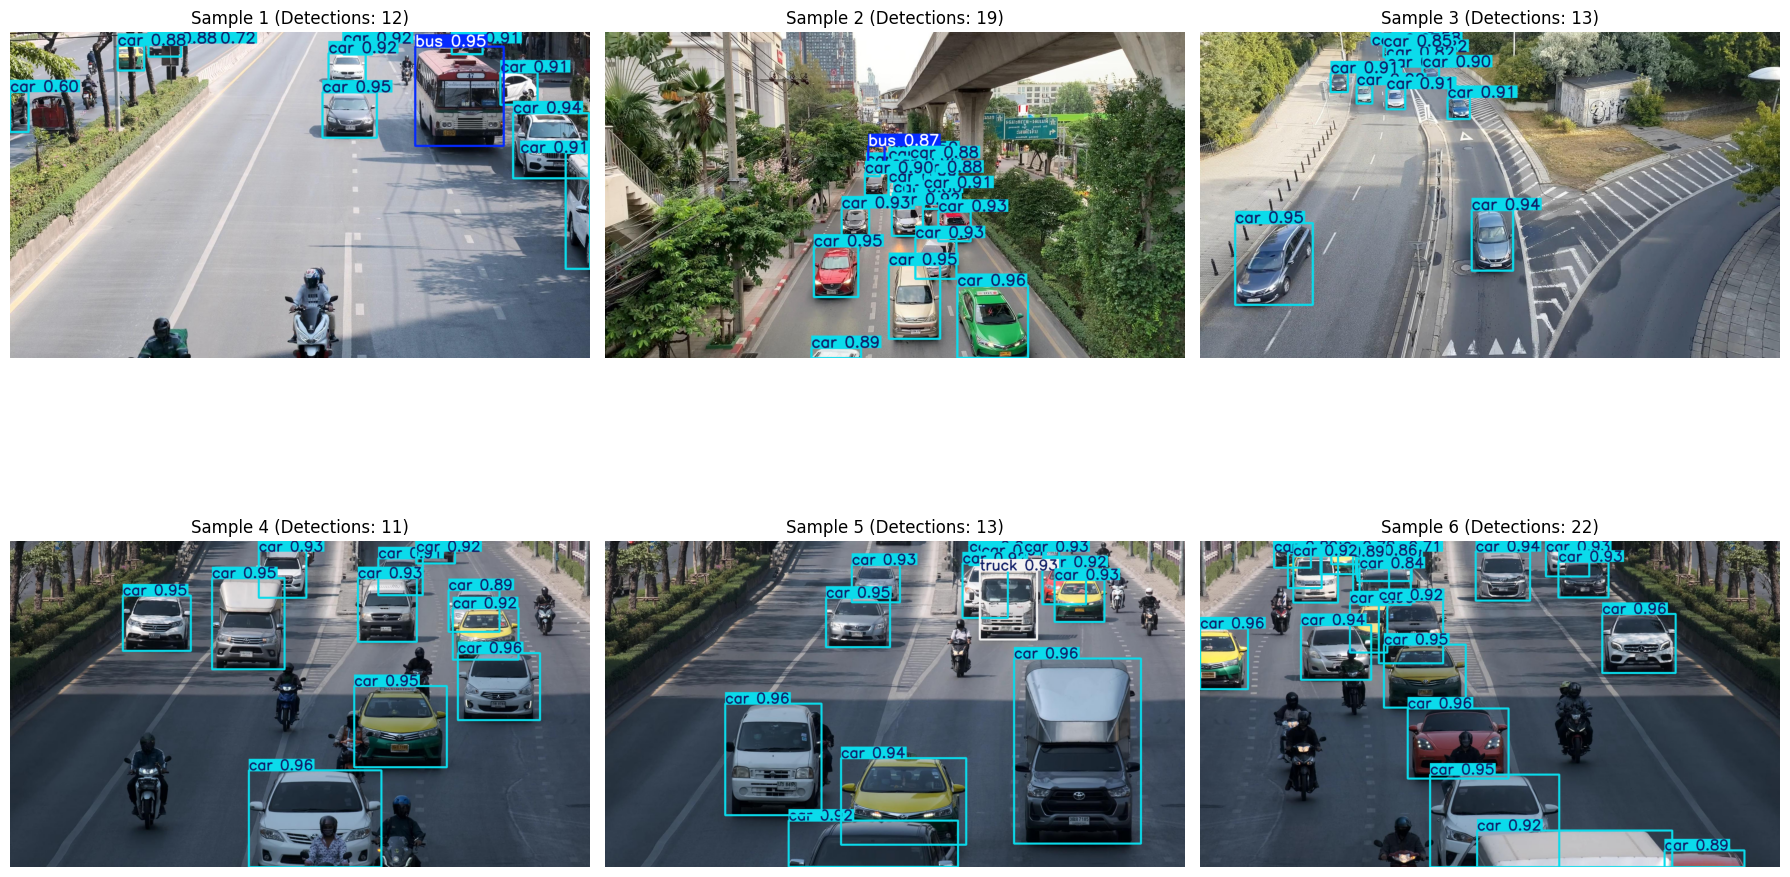

User>> Đã lưu các ảnh dự đoán mẫu vào thư mục: /kaggle/working/predictions_samples


In [13]:

test_images_dir = '/kaggle/input/datasets/miladbayat/surveillance-cameras/SurveillanceCameras/test/images'
output_vis_dir = '/kaggle/working/predictions_samples'
os.makedirs(output_vis_dir, exist_ok=True)

# Lấy danh sách 6 ảnh mẫu từ tập test
sample_images = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:6]

print("\nUser>> Đang chạy dự đoán và trực quan hóa kết quả...")
results = model.predict(
    source=sample_images,
    conf=0.25,        # Threshold độ tin cậy
    iou=0.45,        # NMS IoU threshold
    save=False       # Tự vẽ bằng OpenCV để hiển thị đẹp trên Notebook
)

# Vẽ và hiển thị ảnh kết quả
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (result, img_path) in enumerate(zip(results, sample_images)):
    # BGR -> RGB
    annotated_img = result.plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Lưu ảnh ra đĩa
    save_path = os.path.join(output_vis_dir, f"sample_{idx+1}.jpg")
    cv2.imwrite(save_path, annotated_img)
    
    # Hiển thị trên Notebook
    axes[idx].imshow(annotated_img_rgb)
    axes[idx].set_title(f"Sample {idx+1} (Detections: {len(result.boxes)})")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print(f"User>> Đã lưu các ảnh dự đoán mẫu vào thư mục: {output_vis_dir}")